# Inspect ClArTTS test split (parquet)

This notebook loads **`clartts/test-*.parquet`** (same layout as in `tests/test_ttsdataset_actual_parquet.py`), shows schema and transcripts, and plays waveforms in the browser.

**Prerequisite:** Download or place the test parquet under the project folder, e.g. `clartts/test-00000-of-00001.parquet` (the `clartts/` directory is gitignored).

In [ ]:
from pathlib import Path
import glob
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display


def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / ".." /  "commons" / "dataset.py").exists():
            return p
        p = p.parent
    return Path.cwd().resolve()


ROOT = find_repo_root()
print("Project root:", ROOT)

test_files = sorted(glob.glob(str(ROOT / "clartts" / "test*.parquet")))
if not test_files:
    raise FileNotFoundError(
        "No test parquet found. Expected files like clartts/test-00000-of-00001.parquet under "
        + str(ROOT)
    )
print("Parquet files:", test_files)
PARQUET = test_files[0]
if len(test_files) > 1:
    print(f"(Using first file; set PARQUET manually to pick another)")

Project root: C:\Users\user\Documents\Semester 11\Course Project 2\tacotron2-wavernn
Parquet files: ['C:\\Users\\user\\Documents\\Semester 11\\Course Project 2\\tacotron2-wavernn\\clartts\\test-00000-of-00001.parquet']


In [3]:
df = pd.read_parquet(PARQUET)
print("Rows:", len(df))
print("Columns:", list(df.columns))
df.head(3)

Rows: 205
Columns: ['text', 'file', 'audio', 'sampling_rate', 'duration']


,text,file,audio,sampling_rate,duration
0,صَائِرٌ خَبَرًا فَكُنْ خَبَرًا يَرُوقُ جَمِيلَا,ch_11_arabic_tts_dataset_328.wav,"[-0.001678466796875, -0.00164794921875, -0.001...",40100,3.75
1,أَذُكِرَتْ أَنْجَبَتْ الْتِمَاسُ مَنْ يَتَوَلَ...,ch_09_arabic_tts_dataset_467.wav,"[-0.00054931640625, -0.00054931640625, -0.0005...",40100,4.25
2,فَإِنَّ الْمَرْءَ عَدُوُّ مَا جَهِلَ وَأَنَا أ...,ch_02_arabic_tts_dataset_192.wav,"[-0.000579833984375, 0.0003662109375, 0.000457...",40100,6.45


Index 0 | native 40100 Hz, 3.75s  ->  resampled 16000 Hz, 3.75s
Text: صَائِرٌ خَبَرًا فَكُنْ خَبَرًا يَرُوقُ جَمِيلَا


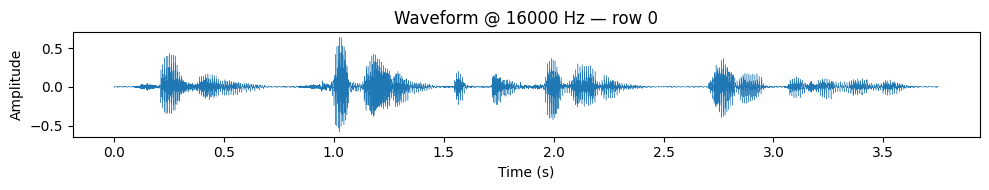

In [7]:
import torch
import torchaudio

TARGET_SR = 16000


def resample_preserve_timing(wav: np.ndarray, orig_sr: int, target_sr: int = TARGET_SR) -> np.ndarray:
    """Band-limited resample: playback at `target_sr` keeps the same pitch and speed as the original recording."""
    if orig_sr == target_sr:
        return np.asarray(wav, dtype=np.float32)
    x = torch.from_numpy(np.asarray(wav, dtype=np.float32)).unsqueeze(0)
    y = torchaudio.functional.resample(x, orig_freq=orig_sr, new_freq=target_sr)
    return y.squeeze(0).numpy()


def row_audio_to_numpy(audio, row) -> tuple[np.ndarray, int]:
    """Return (waveform float32 1-D, native sample_rate). ClArTTS uses 40100 Hz; HF parquet has `sampling_rate`."""
    sr = 22050
    if hasattr(row, "index"):
        for key in ("sampling_rate", "sr", "sample_rate"):
            if key not in row.index:
                continue
            v = row[key]
            if v is None or (isinstance(v, float) and np.isnan(v)):
                continue
            try:
                sr = int(v)
                break
            except (TypeError, ValueError):
                pass

    if isinstance(audio, dict):
        if "array" in audio:
            arr = np.asarray(audio["array"], dtype=np.float32)
            sr = int(audio.get("sampling_rate", sr))
            return arr.reshape(-1), sr
        if "bytes" in audio and audio["bytes"] is not None:
            t, sr = torchaudio.load(io.BytesIO(audio["bytes"]))
            return t.squeeze(0).numpy().astype(np.float32), int(sr)

    if isinstance(audio, (np.ndarray, list)):
        return np.asarray(audio, dtype=np.float32).reshape(-1), sr

    if isinstance(audio, (bytes, bytearray)):
        return np.frombuffer(audio, dtype=np.float32).copy(), sr

    raise TypeError(f"Unsupported audio column type: {type(audio)}")


def show_sample(idx: int):
    row = df.iloc[idx]
    text = row.get("text", row.get("normalized_transcript", ""))
    wav_in, sr_in = row_audio_to_numpy(row["audio"], row)
    wav = resample_preserve_timing(wav_in, sr_in, TARGET_SR)
    dur_native = len(wav_in) / sr_in
    dur_rs = len(wav) / TARGET_SR
    print(f"Index {idx} | native {sr_in} Hz, {dur_native:.2f}s  ->  resampled {TARGET_SR} Hz, {dur_rs:.2f}s")
    print("Text:", text)
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.plot(np.arange(len(wav)) / TARGET_SR, wav, lw=0.3)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Waveform @ {TARGET_SR} Hz — row {idx}")
    plt.tight_layout()
    plt.show()
    display(Audio(wav, rate=TARGET_SR))


show_sample(0)

Index 0 | native 40100 Hz, 3.75s  ->  resampled 16000 Hz, 3.75s
Text: صَائِرٌ خَبَرًا فَكُنْ خَبَرًا يَرُوقُ جَمِيلَا


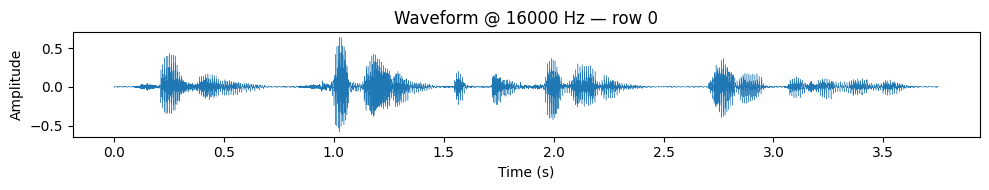

Index 1 | native 40100 Hz, 4.25s  ->  resampled 16000 Hz, 4.25s
Text: أَذُكِرَتْ أَنْجَبَتْ الْتِمَاسُ مَنْ يَتَوَلَى تَدْبِيرَ الْمَنْزِلِ


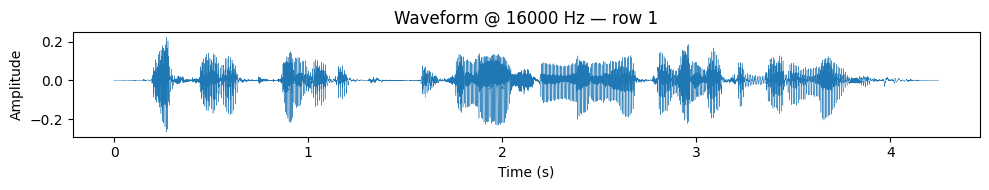

Index 2 | native 40100 Hz, 6.45s  ->  resampled 16000 Hz, 6.45s
Text: فَإِنَّ الْمَرْءَ عَدُوُّ مَا جَهِلَ وَأَنَا أَكْرَهُ أَنْ تَكُونَ عَدُوَّ شَيْءٍ مِنْ الْعِلْمِ


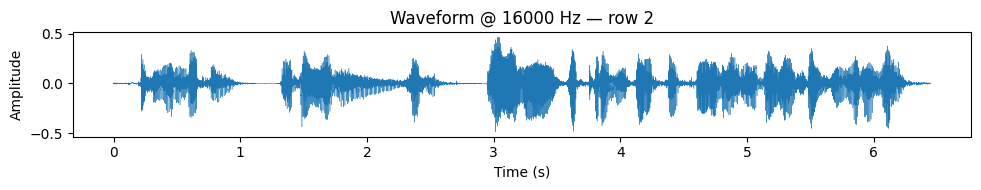

Index 3 | native 40100 Hz, 3.92s  ->  resampled 16000 Hz, 3.92s
Text: وَالثَّانِي مَا تَجَاوَزَهُ إلَى غَيْرِهِ وَذَلِكَ أَرْبَعَةُ أَشْيَاءَ


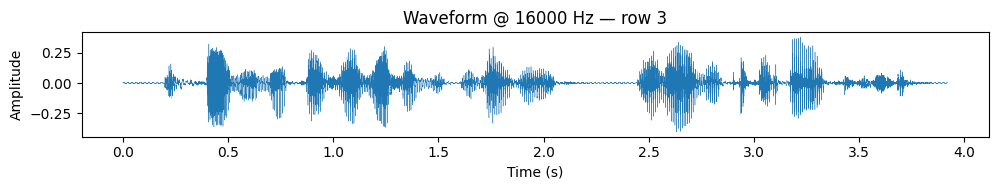

Index 4 | native 40100 Hz, 6.65s  ->  resampled 16000 Hz, 6.65s
Text: بِالْمَحْصُولِ مِنْ رِيَبِك وَهَذَا أَمْرٌ يَنْبَغِي لِلْعَاقِلِ أَنْ يَضْبِطَ نَفْسَهُ


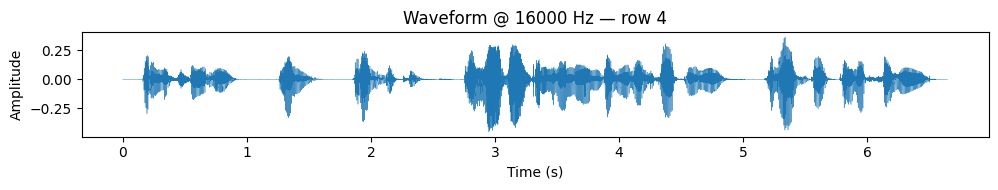

Index 5 | native 40100 Hz, 4.41s  ->  resampled 16000 Hz, 4.41s
Text: وَإِنْ رَأَى فِيهَا سُوءًا اعْتَقَدَهُ فِي النَّاسِ وَقَدْ قِيلَ فِي الْمَثَلِ


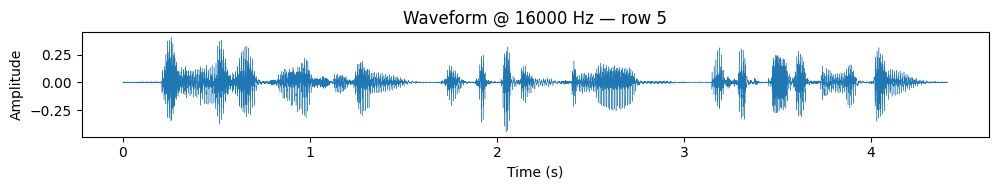

Index 6 | native 40100 Hz, 3.85s  ->  resampled 16000 Hz, 3.85s
Text: عَنْ أَبِي لَهَبٍ وَقَدْ يَحْكُمُ الْأَيَّامَ مَنْ كَانَ جَاهِلًا


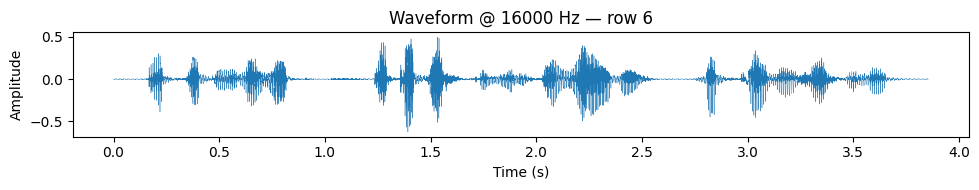

Index 7 | native 40100 Hz, 5.61s  ->  resampled 16000 Hz, 5.61s
Text: وَيَحْجِزُهُمْ عَنْ تَصَرُّفِهِمْ وَيَكُفُّهُمْ عَنْ أَسْبَابِ الْمَوَادِّ الَّتِي بِهَا قِوَامُ


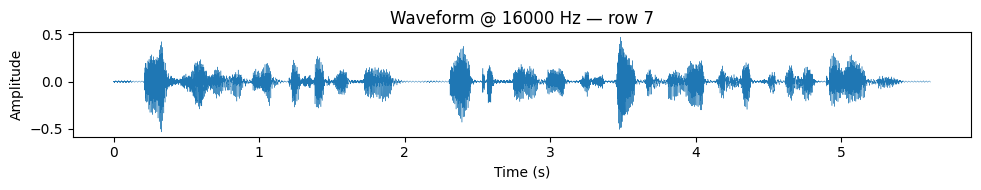

Index 8 | native 40100 Hz, 5.26s  ->  resampled 16000 Hz, 5.26s
Text: عَلَى عُمَرَ بْنِ الْخَطَّابِ  رَضِيَ اللَّهُ عَنْهُ  فَقَالَ مَا هَذَا قَالُوا صَدَاقُ أُمِّ كُلْثُومٍ


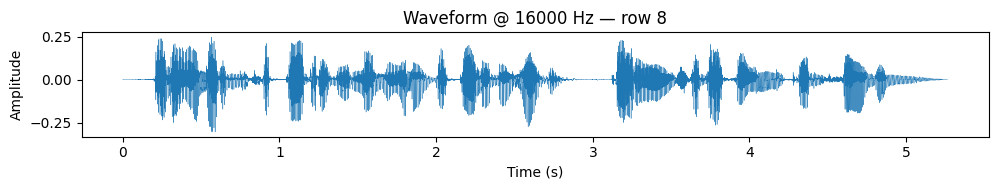

Index 9 | native 40100 Hz, 4.76s  ->  resampled 16000 Hz, 4.76s
Text: وَلَهَا يَسْتَعِدُّ وَمَنْ فَسَدَتْ حَالُهُ مَعَ صَلَاحِ الدُّنْيَا


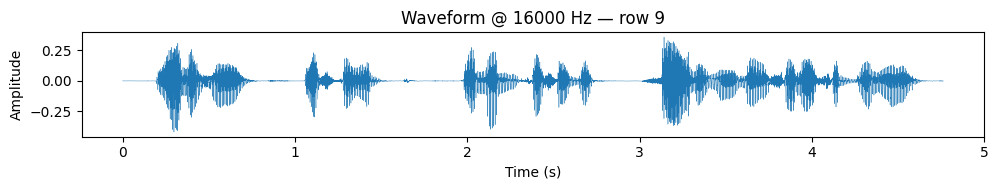

In [9]:
# Browse more rows (change indices)
for i in range(10):
    if i < len(df):
        show_sample(i)